# M4 — Anomalies sur commissions et frais (v2 corrigée)

**Orange Money | Koceila SALEM**

## Corrections vs v1
- **Exclusion des jours partiels** (29-31 août, 30 sept incomplets)
- **Métriques normalisées** : taux de commission (comm/montant) au lieu d'écarts bruts
  → un CASHOUT anormal = taux qui dévie, PAS volume élevé
- **Z-score sur métriques normalisées** par service
- **Sauvegarde stats_par_service** → prêt pour l'inférence (Z-score figé)

## Pourquoi cette correction
L'écart brut `comm_payée - comm_reçue` est structurellement énorme pour CASHOUT
(Orange paie les agents, ne reçoit rien) — c'est le modèle économique NORMAL,
pas une fuite. On cherche les déviations du TAUX habituel de chaque service.

## 0. Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json, time, warnings
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

from src import config as cfg
from src.data_loader import load_parquet
from src import utils

MODEL_DIR  = cfg.MODELS_DIR / 'M4_commissions'
OUTPUT_DIR = cfg.OUTPUTS_DIR / 'M4_commissions'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Imports OK')

Imports OK


## 1. Chargement

In [2]:
COLS_M4 = [cfg.COL_DATE, cfg.COL_SERVICE,
    cfg.COL_COMM_PAID, cfg.COL_COMM_RECV, cfg.COL_COMM_OTHER,
    cfg.COL_SCHARGE_RCV, cfg.COL_SCHARGE_PAID, cfg.COL_MONTANT]
df = load_parquet(columns=COLS_M4)

cols_comm = [cfg.COL_COMM_PAID, cfg.COL_COMM_RECV, cfg.COL_COMM_OTHER,
             cfg.COL_SCHARGE_RCV, cfg.COL_SCHARGE_PAID]
for c in cols_comm:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df[cfg.COL_MONTANT] = pd.to_numeric(df[cfg.COL_MONTANT], errors='coerce').fillna(0)

Chargé en 0.3s
Dimensions : 25,456,467 lignes × 8 colonnes
RAM        : 1.64 Go
Plage      : 2025-08-29 10:35:20 → 2025-09-30 23:59:59


Jours      : 32


## 2. Agrégation + EXCLUSION des jours partiels

In [3]:
df['_jour'] = df[cfg.COL_DATE].dt.date

# Volume par jour pour détecter les jours partiels
vol_jour = df.groupby('_jour').size()
vol_median = vol_jour.median()
# Jour partiel = moins de 50% du volume médian
jours_partiels = vol_jour[vol_jour < 0.5 * vol_median].index.tolist()
print(f'Volume médian/jour : {vol_median:,.0f}')
print(f'Jours partiels exclus ({len(jours_partiels)}) : {jours_partiels}')

df_clean = df[~df['_jour'].isin(jours_partiels)].copy()
print(f'Lignes après exclusion : {len(df_clean):,} (sur {len(df):,})')

# Agrégation jour × service
agg = df_clean.groupby(['_jour', cfg.COL_SERVICE], observed=True).agg(
    nb_tx         = (cfg.COL_MONTANT, 'count'),
    montant_total = (cfg.COL_MONTANT, 'sum'),
    comm_paid     = (cfg.COL_COMM_PAID, 'sum'),
    comm_recv     = (cfg.COL_COMM_RECV, 'sum'),
    comm_other    = (cfg.COL_COMM_OTHER, 'sum'),
    scharge_recv  = (cfg.COL_SCHARGE_RCV, 'sum'),
    scharge_paid  = (cfg.COL_SCHARGE_PAID, 'sum'),
).reset_index()

# Garder seulement les services à activité réelle (au moins 100 tx/jour en moyenne)
svc_actifs = agg.groupby(cfg.COL_SERVICE, observed=True)['nb_tx'].mean()
svc_actifs = svc_actifs[svc_actifs >= 100].index.tolist()
agg = agg[agg[cfg.COL_SERVICE].isin(svc_actifs)].reset_index(drop=True)
print(f'\nServices actifs retenus : {svc_actifs}')
print(f'Agrégats : {len(agg)} lignes')

Volume médian/jour : 869,752
Jours partiels exclus (2) : [datetime.date(2025, 8, 29), datetime.date(2025, 8, 31)]


Lignes après exclusion : 25,456,240 (sur 25,456,467)



Services actifs retenus : ['B2BCASHOUT', 'CASHIN', 'CASHOUT', 'ENT2REG', 'MERCHPAY', 'P2P', 'RC', 'ROLLBACK', 'TXNCORRECT']
Agrégats : 267 lignes


## 3. MÉTRIQUES NORMALISÉES (le cœur de la correction)

On normalise par le volume pour comparer des jours comparables.

In [4]:
# Écart brut (gardé pour info/montant)
agg['ecart_comm'] = agg['comm_paid'] - agg['comm_recv']

# ── MÉTRIQUES NORMALISÉES (insensibles au volume) ──
# Taux de commission payée = commission / montant transigé
agg['taux_comm_paid'] = agg['comm_paid'] / (agg['montant_total'] + 1)
# Taux de service charge
agg['taux_scharge']   = agg['scharge_recv'] / (agg['montant_total'] + 1)
# Commission moyenne par transaction
agg['comm_par_tx']    = agg['comm_paid'] / (agg['nb_tx'] + 1)
# Service charge par transaction
agg['scharge_par_tx'] = agg['scharge_recv'] / (agg['nb_tx'] + 1)
# Ratio commission reçue / payée (détecte les déséquilibres)
agg['ratio_recv_paid']= agg['comm_recv'] / (agg['comm_paid'] + 1)

print('Métriques normalisées par service (moyennes) :')
print(agg.groupby(cfg.COL_SERVICE, observed=True)[
    ['taux_comm_paid','comm_par_tx','scharge_par_tx']].mean().to_string())

Métriques normalisées par service (moyennes) :
              taux_comm_paid  comm_par_tx  scharge_par_tx
SERVICE_TYPE                                             
B2BCASHOUT      3.938915e-03  1548.563972     3831.357511
CASHIN          1.713817e-03   189.392867      113.157264
CASHOUT         5.196754e-03   490.534148     1192.272755
ENT2REG         0.000000e+00     0.000000      878.188293
MERCHPAY        2.049488e-10     0.000003       43.188543
P2P             5.258187e-05    12.932724      557.192230
RC              1.987774e-02    26.980840        0.000000
ROLLBACK        0.000000e+00     0.000000        0.000000
TXNCORRECT      0.000000e+00     0.000000        0.000000


## 4. Z-score sur métriques normalisées (par service)

In [5]:
# Stats par service (à SAUVEGARDER pour inférence — Z-score figé)
METRIQUES_Z = ['taux_comm_paid', 'comm_par_tx', 'scharge_par_tx']

stats_par_service = {}
for m in METRIQUES_Z:
    g = agg.groupby(cfg.COL_SERVICE, observed=True)[m]
    stats_par_service[m] = {
        'mean': g.mean().to_dict(),
        'std':  g.std().to_dict(),
    }
    # Z-score
    agg[f'z_{m}'] = agg.groupby(cfg.COL_SERVICE, observed=True)[m].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9))

# Z-score combiné (max absolu des 3 métriques)
z_cols = [f'z_{m}' for m in METRIQUES_Z]
agg['zscore_max'] = agg[z_cols].abs().max(axis=1)

SEUIL_Z = 2.5
agg['anomalie_zscore'] = (agg['zscore_max'] > SEUIL_Z).astype(int)
print(f'Anomalies Z-score (|Z|>{SEUIL_Z}) : {agg["anomalie_zscore"].sum()} / {len(agg)}')
print('\nTop 10 déviations de taux :')
top_z = agg.sort_values('zscore_max', ascending=False).head(10)
print(top_z[['_jour', cfg.COL_SERVICE, 'taux_comm_paid', 'comm_par_tx', 'zscore_max']].to_string(index=False))

Anomalies Z-score (|Z|>2.5) : 8 / 267

Top 10 déviations de taux :
     _jour SERVICE_TYPE  taux_comm_paid  comm_par_tx  zscore_max
2025-09-20      ENT2REG    0.000000e+00     0.000000    3.743470
2025-09-21          P2P    1.601270e-04    10.700002    3.545330
2025-09-24     MERCHPAY    2.017691e-09     0.000033    3.457817
2025-09-25     MERCHPAY    2.239203e-09     0.000031    3.165004
2025-09-15           RC    9.537360e-03    28.601096    3.098740
2025-09-14   B2BCASHOUT    5.741855e-03   706.098361    2.701313
2025-09-14      CASHOUT    6.375819e-03   359.156360    2.687436
2025-09-01          P2P    4.086944e-05    16.774209    2.543500
2025-09-21           RC    1.749525e-02    21.656844    2.481636
2025-09-07           RC    1.738990e-02    21.724367    2.450162


## 5. Isolation Forest sur métriques normalisées

In [6]:
# IF sur les métriques NORMALISÉES (pas les volumes bruts)
FEAT_M4 = ['taux_comm_paid', 'taux_scharge', 'comm_par_tx',
           'scharge_par_tx', 'ratio_recv_paid']

X = agg[FEAT_M4].fillna(0).values
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=200, contamination=0.05,
                      random_state=cfg.RANDOM_SEED, n_jobs=-1)
iso.fit(X_scaled)
scores = iso.score_samples(X_scaled)
agg['RISK_SCORE'], score_meta = utils.score_to_risk(scores, method='percentile')
agg['anomalie_if'] = (iso.predict(X_scaled) == -1).astype(int)

print(f'Anomalies IF (5%) : {agg["anomalie_if"].sum()} / {len(agg)}')
print('\nTop 10 anomalies IF (sur métriques normalisées) :')
top_if = agg.sort_values('RISK_SCORE', ascending=False).head(10)
print(top_if[['_jour', cfg.COL_SERVICE, 'taux_comm_paid', 'comm_par_tx', 'RISK_SCORE']].to_string(index=False))

Anomalies IF (5%) : 14 / 267

Top 10 anomalies IF (sur métriques normalisées) :
     _jour SERVICE_TYPE  taux_comm_paid  comm_par_tx  RISK_SCORE
2025-09-26      ENT2REG        0.000000     0.000000  100.000000
2025-09-16   B2BCASHOUT        0.003041  2030.341772   99.625468
2025-09-20      ENT2REG        0.000000     0.000000   99.250936
2025-09-15   B2BCASHOUT        0.002957  1891.970588   98.876404
2025-09-09   B2BCASHOUT        0.003437  1947.931818   98.501873
2025-09-23   B2BCASHOUT        0.003115  1981.091463   98.127341
2025-09-20     MERCHPAY        0.000000     0.000000   97.752809
2025-09-07   B2BCASHOUT        0.003514  1165.541284   97.378277
2025-09-08   B2BCASHOUT        0.003055  1943.308511   97.003745
2025-09-14      ENT2REG        0.000000     0.000000   96.629213


## 6. Fusion + montant estimé de la fuite

In [7]:
agg['ALERTE'] = ((agg['anomalie_zscore']==1) | (agg['anomalie_if']==1)).astype(int)
agg['confiance'] = agg['anomalie_zscore'] + agg['anomalie_if']

alertes = agg[agg['ALERTE']==1].copy()

# Montant estimé de la fuite : écart entre le taux observé et le taux normal du service
taux_normal = agg.groupby(cfg.COL_SERVICE, observed=True)['taux_comm_paid'].transform('median')
agg['fuite_estimee'] = ((agg['taux_comm_paid'] - taux_normal) * agg['montant_total']).clip(lower=0)
alertes = agg[agg['ALERTE']==1].copy()

print(f'Total alertes : {len(alertes)} / {len(agg)}')
print(f'  Haute confiance (2 méthodes) : {(agg["confiance"]==2).sum()}')
print(f'  Fuite estimée totale : {utils.format_montant(alertes["fuite_estimee"].sum())}')

print('\n=== Alertes haute confiance ===')
haute = agg[agg['confiance']==2].sort_values('RISK_SCORE', ascending=False)
if len(haute) > 0:
    print(haute[['_jour', cfg.COL_SERVICE, 'taux_comm_paid', 'comm_par_tx',
                 'zscore_max', 'RISK_SCORE', 'fuite_estimee']].to_string(index=False))
else:
    print('Aucune — voir les alertes simple méthode ci-dessous')
    print(alertes.sort_values('RISK_SCORE', ascending=False).head(10)[
        ['_jour', cfg.COL_SERVICE, 'taux_comm_paid', 'zscore_max', 'RISK_SCORE']].to_string(index=False))

Total alertes : 20 / 267
  Haute confiance (2 méthodes) : 2
  Fuite estimée totale : 7.6 M MGA

=== Alertes haute confiance ===
     _jour SERVICE_TYPE  taux_comm_paid  comm_par_tx  zscore_max  RISK_SCORE  fuite_estimee
2025-09-20      ENT2REG        0.000000      0.00000    3.743470   99.250936   0.000000e+00
2025-09-14      CASHOUT        0.006376    359.15636    2.687436   95.131086   6.949585e+06


## 7. Visualisations

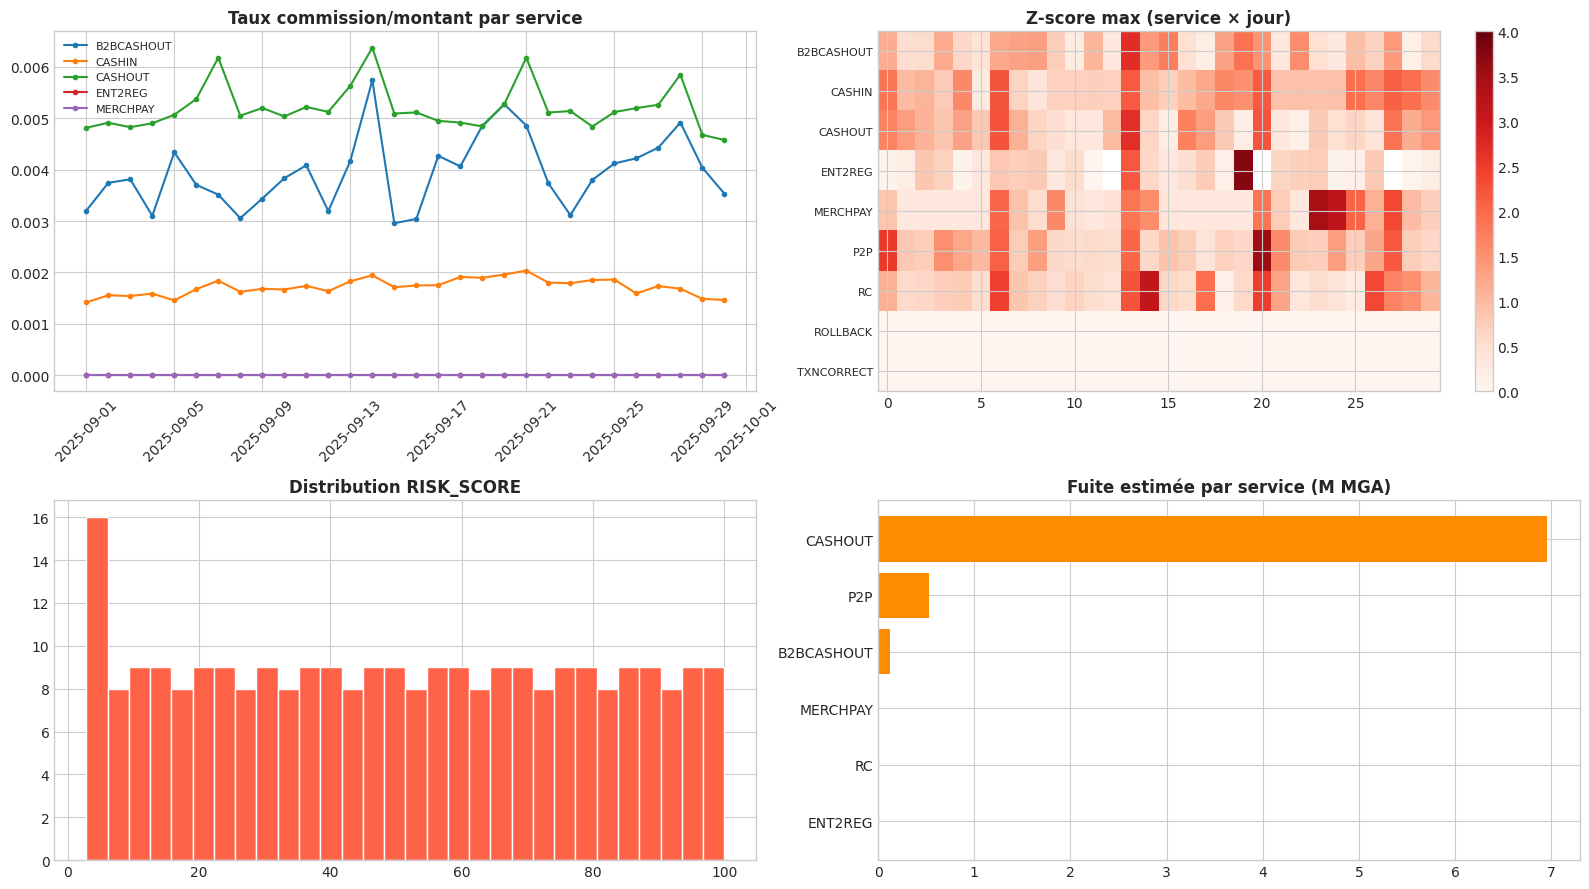

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# 1. Taux de commission par service dans le temps
for svc in svc_actifs[:5]:
    sub = agg[agg[cfg.COL_SERVICE]==svc].sort_values('_jour')
    axes[0,0].plot(sub['_jour'], sub['taux_comm_paid'], marker='.', label=svc)
axes[0,0].set_title('Taux commission/montant par service', fontweight='bold')
axes[0,0].legend(fontsize=8); axes[0,0].tick_params(axis='x', rotation=45)

# 2. Heatmap Z-score
pivot = agg.pivot_table(index=cfg.COL_SERVICE, columns='_jour', values='zscore_max', observed=True)
im = axes[0,1].imshow(pivot.values, aspect='auto', cmap='Reds', vmin=0, vmax=4)
axes[0,1].set_yticks(range(len(pivot.index))); axes[0,1].set_yticklabels(pivot.index, fontsize=8)
axes[0,1].set_title('Z-score max (service × jour)', fontweight='bold')
plt.colorbar(im, ax=axes[0,1])

# 3. Distribution RISK_SCORE
axes[1,0].hist(agg['RISK_SCORE'], bins=30, color='tomato', edgecolor='white')
axes[1,0].set_title('Distribution RISK_SCORE', fontweight='bold')

# 4. Fuite estimée par service
fuite_svc = alertes.groupby(cfg.COL_SERVICE, observed=True)['fuite_estimee'].sum().sort_values()
if len(fuite_svc) > 0:
    axes[1,1].barh(fuite_svc.index, fuite_svc.values/1e6, color='darkorange')
    axes[1,1].set_title('Fuite estimée par service (M MGA)', fontweight='bold')

plt.tight_layout(); plt.savefig(OUTPUT_DIR/'m4_analyse.png', dpi=150); plt.show()

## 8. Export (prêt pour inférence)

In [9]:
joblib.dump(iso, MODEL_DIR/'iforest.pkl')
joblib.dump(scaler, MODEL_DIR/'scaler.pkl')

# params + stats_par_service (POUR L'INFÉRENCE : Z-score figé)
params = {
    'FEATURES': FEAT_M4,
    'METRIQUES_Z': METRIQUES_Z,
    'SEUIL_Z': SEUIL_Z,
    'contamination': 0.05,
    'score_calibration': score_meta,
    'stats_par_service': stats_par_service,
    'services_actifs': svc_actifs,
    'jours_partiels_exclus': [str(j) for j in jours_partiels],
    'vol_median_jour': float(vol_median),
    'n_agregats': int(len(agg)),
}
with open(MODEL_DIR/'params.json','w') as f:
    json.dump(params, f, indent=2, default=str)

agg.to_parquet(OUTPUT_DIR/'scored.parquet', index=False)
alertes.sort_values('RISK_SCORE', ascending=False)\
    .to_csv(OUTPUT_DIR/'alertes.csv', index=False, encoding='utf-8-sig')

print('Exports créés dans outputs/M4_commissions/ et models/M4_commissions/')
print('  + stats_par_service sauvegardé -> prêt pour inférence (Z-score figé)')
print(f'\n=== RÉSUMÉ M4 v2 ===')
print(f'Agrégats     : {len(agg)} (jours partiels exclus)')
print(f'Services     : {len(svc_actifs)}')
print(f'Alertes      : {len(alertes)}')
print(f'Haute conf.  : {(agg["confiance"]==2).sum()}')
print(f'Fuite estimée: {utils.format_montant(alertes["fuite_estimee"].sum())}')

Exports créés dans outputs/M4_commissions/ et models/M4_commissions/
  + stats_par_service sauvegardé -> prêt pour inférence (Z-score figé)

=== RÉSUMÉ M4 v2 ===
Agrégats     : 267 (jours partiels exclus)
Services     : 9
Alertes      : 20
Haute conf.  : 2
Fuite estimée: 7.6 M MGA
